# Análise Exploratória dos Dados: Otimização dos parâmetros de soldagem

#### Objetivo Geral
Analisar o comportamento estatístico e físico dos dados para estruturar o script de pré-processamento e o código de modelagem (Regressão Multi-Output em PyTorch com ajuste de hiperparâmetros via Optuna).

####  Roteiro da Análise
1. Preparação e Unificação dos Dados: Unificação dos dados por tipo de passe (Raiz, Enchimento e Acabamento).
2. Diagnóstico e Tratamento dos Dados Ausentes: Tratamento de valores nulos e correção de textos/unidades.
3. Tratamento Textual dos Dados: Limpeza, padronização e conversão de variáveis de texto para formato numérico.
4. Análise Estatística dos Alvos: Análise da distribuição estatística e identificação de outliers operacionais.
5. Estudo da Correlação: Estudo de correlações não-lineares.
6. Análise das Variáveis: Verificação do volume de dados únicos e geração do checklist com as regras de negócio para o código de pré processamento dos dados.

In [1]:
#Bibliotecas Utilizadas

# Sistema e Ambiente
import os
from pathlib import Path
from dotenv import load_dotenv

# Manipulação e Análise de Dados
import numpy as np
import pandas as pd

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns


### 1. Preparação e Unificação dos Dados

In [2]:
load_dotenv()
DATA_PATH = os.getenv("CAMINHO_DADOS")
df = pd.read_csv(DATA_PATH, sep=';')

In [3]:
df.columns

Index(['documento_origem', 'numero_rqps', 'normas_referencia',
       'material1_especificacao', 'material1_pnumber', 'material1_espessura',
       'material1_diametro', 'material2_especificacao', 'material2_pnumber',
       'material2_espessura', 'material2_diametro', 'posicao_peca',
       'progressao', 'cobre_junta', 'goivagem', 'tipo_chanfro', 'angulo',
       'nariz', 'abertura_raiz', 'raiz_processo', 'raiz_especificacao',
       'raiz_classificacao', 'raiz_diametro', 'enchimento_processo',
       'enchimento_especificacao', 'enchimento_classificacao',
       'enchimento_diametro', 'acabamento_processo',
       'acabamento_especificacao', 'acabamento_classificacao',
       'acabamento_diametro', 'tipo_gas_tocha_raiz',
       'tipo_gas_tocha_acabamento', 'pureza_gas_tocha_raiz',
       'pureza_gas_tocha_acabamento', 'vazao_gas_tocha_raiz',
       'vazao_gas_tocha_acabamento', 'tipo_gas_purga_raiz',
       'tipo_gas_purga_acabamento', 'pureza_gas_purga_raiz',
       'pureza_gas_purg

In [4]:
# Trata os nulos do diâmetro e cria a classificação 
df['material1_diametro'] = pd.to_numeric(df['material1_diametro'], errors='coerce').fillna(0.0)
df['tipo_peca'] = np.where(df['material1_diametro'] > 0, 'tubo', 'chapa')

In [5]:
colunas_comuns = [
    # norma
    'normas_referencia',

    # material de base
    'material1_pnumber',
    'material1_especificacao',
    'material1_espessura',
    'material1_diametro',
    'tipo_peca',

    # junta
    'tipo_chanfro',
    'angulo',
    'nariz',
    'abertura_raiz',
    'cobre_junta',
    'goivagem',

    # posição
    'posicao_peca',
    'progressao',

    # temperatura
    'pre_aquecimento',
    'temperatura_interpasse'
]

In [6]:
passes = {
    'raiz': {
        'processo': 'raiz_processo',
        'classificacao': 'raiz_classificacao',
        'diametro': 'raiz_diametro',
        'polaridade': 'raiz_polaridade',
        'limpeza': 'raiz_limpeza', 
        'voltagem': 'raiz_voltagem',
        'amperagem': 'raiz_amperagem',
        'velocidade_de_soldagem': 'raiz_vel_soldagem',
        'tipo_gas_tocha': 'tipo_gas_tocha_raiz',
        'vazao_gas_tocha': 'vazao_gas_tocha_raiz',
        'pureza_gas_tocha': 'pureza_gas_tocha_raiz',
        'tipo_gas_purga': 'tipo_gas_purga_raiz',
        'vazao_gas_purga': 'vazao_gas_purga_raiz',
        'pureza_gas_purga':'pureza_gas_purga_raiz'
        
    },

    'enchimento': {
        'processo': 'enchimento_processo',
        'classificacao': 'enchimento_classificacao',
        'diametro': 'enchimento_diametro',
        'polaridade': 'enchimento_polaridade',
        'limpeza': 'enchimento_limpeza',
        'voltagem': 'enchimento_voltagem',
        'amperagem': 'enchimento_amperagem',
        'velocidade_de_soldagem': 'enchimento_vel_soldagem',
        'tipo_gas_tocha': 'tipo_gas_tocha_acabamento', # Herda do acabamento
        'vazao_gas_tocha': 'vazao_gas_tocha_acabamento', # Herda do acabamento
        'pureza_gas_tocha': 'pureza_gas_tocha_acabamento', #Herda do acabamento
        'tipo_gas_purga': 'tipo_gas_purga_acabamento', # Herda do acabamento
        'vazao_gas_purga': 'vazao_gas_purga_acabamento',# Herda do acabamento
        'pureza_gas_purga': 'pureza_gas_purga_acabamento'# Herda do acabamento
    },

    'acabamento': {
        'processo': 'acabamento_processo',
        'classificacao': 'acabamento_classificacao',
        'diametro': 'acabamento_diametro',
        'polaridade': 'acabamento_polaridade',
        'limpeza': 'acabamento_limpeza',
        'voltagem': 'acabamento_voltagem',
        'amperagem': 'acabamento_amperagem',    
        'velocidade_de_soldagem': 'acabamento_vel_soldagem',
        'tipo_gas_tocha': 'tipo_gas_tocha_acabamento',
        'vazao_gas_tocha': 'vazao_gas_tocha_acabamento',
        'pureza_gas_tocha': 'pureza_gas_tocha_acabamento',
        'tipo_gas_purga': 'tipo_gas_purga_acabamento',
        'vazao_gas_purga': 'vazao_gas_purga_acabamento',
        'pureza_gas_purga': 'pureza_gas_purga_acabamento'
    }
}

In [7]:
dfs = []

for passe, cols in passes.items():
    temp = df[colunas_comuns].copy()
    temp['passe'] = passe
    
    temp['processo'] = df[cols['processo']]
    temp['classificacao'] = df[cols['classificacao']]
    temp['diametro_arame'] = df[cols['diametro']]
    temp['polaridade'] = df[cols['polaridade']]
    temp['limpeza'] = df[cols['limpeza']]
    temp['voltagem'] = df[cols['voltagem']]
    temp['amperagem'] = df[cols['amperagem']]
    temp['velocidade_de_soldagem'] = df[cols['velocidade_de_soldagem']]
    temp['tipo_gas_tocha'] = df[cols['tipo_gas_tocha']]
    temp['vazao_gas_tocha'] = df[cols['vazao_gas_tocha']]
    temp['pureza_gas_tocha'] = df[cols['pureza_gas_tocha']]
    temp['tipo_gas_purga'] = df[cols['tipo_gas_purga']] 
    temp['vazao_gas_purga'] = df[cols['vazao_gas_purga']] 
    temp['pureza_gas_purga'] = df[cols['pureza_gas_purga']]
    dfs.append(temp)

dados = pd.concat(dfs, ignore_index=True)

In [8]:
dados = dados.rename(columns={'classificacao': 'material_adicao'})
dados = dados.rename(columns={'material1_pnumber': 'pnumber'})
dados = dados.rename(columns={'material1_especificacao': 'material_base'})
dados = dados.rename(columns={'material1_espessura': 'espessura'})
dados = dados.rename(columns={'material1_diametro': 'diametro_base'})

In [9]:
dados.shape

(903, 31)

### 2. Diagnóstico e Tratamento dos Dados Ausentes

In [10]:
dados.isna().sum().sort_values(ascending=False)

goivagem                  753
pureza_gas_purga          502
vazao_gas_purga           456
cobre_junta               420
pureza_gas_tocha          245
vazao_gas_tocha           185
velocidade_de_soldagem     81
voltagem                   52
temperatura_interpasse     45
pre_aquecimento            45
amperagem                  18
nariz                      18
diametro_arame             12
angulo                      9
abertura_raiz               9
limpeza                     9
processo                    1
progressao                  0
material_base               0
espessura                   0
diametro_base               0
tipo_peca                   0
tipo_chanfro                0
normas_referencia           0
posicao_peca                0
pnumber                     0
passe                       0
polaridade                  0
material_adicao             0
tipo_gas_tocha              0
tipo_gas_purga              0
dtype: int64

In [11]:
dados['goivagem'].unique()

array([nan, True, False], dtype=object)

In [12]:
dados['cobre_junta'].unique()

array([nan, True, False], dtype=object)

In [13]:
col = ['goivagem', 'cobre_junta']
for c in col:
    dados[c] = dados[c].fillna('Informação Desconhecida')

In [14]:
dados['vazao_gas_purga'].unique()

array([nan, '9.0', '10.0', '25', '18', '8/12', '15', '12', '10/12', '10',
       '20/22', '13', '20', '16', '9', '23', '8/10', '22', '30',
       '10 / 15', '10 / 20', '11/15', '20 / 25', '10/15', '12/20',
       '15/25', '14', '20/25', '15/20', '16 mm'], dtype=object)

In [15]:
dados['vazao_gas_tocha'].unique()

array([nan, '12', '16', '15', '20', '25', '30', '18', '10/10.5', '11',
       '10', '11/13', '15/18', '12/20', '15/20', '14', '10/12', '13/15',
       '20/25', '7.5', '23', '16/30', '22', '9/15', '10/19', '9/16', '19',
       '16/25', '18/20', '19/21', '22/24', '18/22', '8/12', '9.5',
       '13/14', '13-15', '13', '8/10', '18 /20', '7', '8 / 12', '14 / 16',
       '11/15', '15 / 20', '15/25', '17', '17/18', '10/15', '7/12',
       '8/15', '15.0', '20.0', '25.0', '18.0', '12.0', '24', '14/24'],
      dtype=object)

In [16]:
import re 
def limpar_vazao(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).lower().strip()
    val_str = val_str.replace('dez', '12')
    val_str = val_str.replace(' a ', '/').replace('-', '/')
    numeros = re.findall(r'\d+\.\d+|\d+', val_str)
    if not numeros:
        return 0.0
    valores_float = [float(n) for n in numeros]
    return sum(valores_float) / len(valores_float)

cols = ['vazao_gas_purga', 'vazao_gas_tocha']
for c in cols:
   dados[c] = dados[c].apply(limpar_vazao)

In [17]:
dados['pre_aquecimento'] = dados['pre_aquecimento'].fillna(25.0)
dados['temperatura_interpasse'] = dados['temperatura_interpasse'].fillna(dados['temperatura_interpasse'].mean())

In [18]:
dados = dados.dropna(subset=['voltagem', 'amperagem', 'velocidade_de_soldagem','nariz', 'abertura_raiz', 'angulo','diametro_arame','espessura'])

In [19]:
col = ['pureza_gas_purga', 'pureza_gas_tocha']
for c in col:
    dados[c] = dados[c].fillna('Sem Gás')

In [20]:
dados.isna().sum().sort_values(ascending=False)

limpeza                   9
pnumber                   0
normas_referencia         0
espessura                 0
diametro_base             0
tipo_peca                 0
material_base             0
angulo                    0
nariz                     0
abertura_raiz             0
cobre_junta               0
goivagem                  0
posicao_peca              0
progressao                0
tipo_chanfro              0
pre_aquecimento           0
temperatura_interpasse    0
processo                  0
passe                     0
material_adicao           0
diametro_arame            0
polaridade                0
voltagem                  0
amperagem                 0
velocidade_de_soldagem    0
tipo_gas_tocha            0
vazao_gas_tocha           0
pureza_gas_tocha          0
tipo_gas_purga            0
vazao_gas_purga           0
pureza_gas_purga          0
dtype: int64

In [21]:
dados.shape

(770, 31)

Nesta seção, realizamos o tratamento dos valores nulos (NaN) com base em regras de negócio e na física do processo de soldagem, preparando a base para a rede neural.As seguintes ações foram tomadas:

* Variáveis categóricas (goivagem, cobre_junta): Preenchidas com o texto 'Informação Desconhecida', já que a ausência de registro indica que o recurso não foi utilizado.
* Vazões de gás (vazao_gas_purga, vazao_gas_tocha): Tratadas com uma função baseada em Expressões Regulares (re) para extrair e calcular a média de valores textuais complexos (como faixas e intervalos). Valores nulos foram zerados.
* Pureza dos gases: Preenchidas com o texto 'Sem Gás'
* Parâmetros Térmicos: O pre_aquecimento foi substituído por 25.0, representando a temperatura ambiente, e a temperatura de interpasse foi preenchida com a média.
* Geometria, Consumíveis, Espessura e Alvos (nariz, abertura_raiz, angulo, diametro_arame, material1_espessura, voltagem, amperagem, velocidade_de_soldagem): Remoção direta de todas as linhas vazias via .dropna(), garantindo o treinamento do modelo com amostras reais e completas.

### 3. Tratamento de Dados Textuais

In [22]:
dados['normas_referencia'].unique()

array(['AWS D1.1 e N 133 h', 'ASME Seção IX Ed.2007',
       'ASME Seção IX Ed.2007 Add. 2008', 'ASME Seção IX Ed.2010',
       'ASME Seção IX - Ed. 1998/ N133G', 'ASME Seção IX Ed.1998/ N133G',
       'ASME Seção IX Ed. 1999/ N133G', 'ASME Seção IX-Ed. 1999/ N133G',
       'ASME Seção IX/1998 Add. 1999',
       'ASME Seção IX / Ed. 1998 - Add. 1999', 'ASME Seção IX Ed. 2000',
       'ASME Seção IX - 2001', 'ASME Seção IX Ed. 1995/ N133G',
       'ASME Seção IX - Ed. 1995', 'ASME Seção IX Ed. 1995',
       'ASME Seção IX Add. 97', 'AWS D1.1 Edição 2010', 'ASME IX 2013',
       'ASME IX 2010', 'ABS 2010', 'ASME IX 2007', 'ASME IX 2004',
       'ASME IX', 'AWS D1.1 2010', 'AWS D1.1 2008', 'AWS D1.1 2015',
       'AWS D1.1 2016', 'ABS 2015', 'AWS D1.1 2010 / ABS 2010',
       'ASME Seção IX Ed. 1998', 'ASME Seção IX Ed. 1998/ N133G',
       'ASME Seção IX Ed. 1998/ N133J', 'ASME Seção IX',
       'ASME Seção IX Ed. 2004 Add.2006', 'ASME Seção IX Ed. 1997',
       'ASME Seção IX Ed. 1998 A

In [23]:
def limpar_normas_referencia(texto):
    if pd.isna(texto):
        return 'Não Informado'
    texto = str(texto).lower()
    if re.search(r'\baws\b', texto):
        return 'AWS'
    if re.search(r'\basme\b.*\bix\b', texto) or re.search(r'\bix\b.*\basme\b', texto):
        return 'ASME IX'
    if re.search(r'\babs\b', texto):
        return 'ABS'
    if re.search(r'\bastm\b', texto):
        return 'ASME IX'
    return 'Outros'

dados['normas_referencia'] = dados['normas_referencia'].apply(limpar_normas_referencia)

In [24]:
dados['normas_referencia'].unique()

array(['AWS', 'ASME IX', 'ABS'], dtype=object)

In [25]:
dados['limpeza'].unique()

array(['ESMER.', 'ESMER./ESCOV', 'ESCOVAMENTO/ESMERILHAMENTO', 'NAN',
       'ESMER', 'INICIAL: AO METAL BRILHANTE',
       'DISCO ABRASIVO/ESCOVAMENTO', 'DISCO/ESCOVAMENTO',
       'ESMERILHAMENTO/LIXAMENTO', 'ESCOV./ESMER.', 'ESCOV./ESMERIL.',
       nan, 'ESMERIL.', 'LIXAMENTO', 'ESCOV.', 'ESCOV/ESMER',
       'ESMER/ESCOV', 'AO METAL BRILHANTE', 'ESCOV./SOLVENTE',
       'DISCO E ESCOVA DE INOX', 'ESMERILHAMENTO', 'ESCOVAMENTO',
       'ESMERILHAMENTO/ESCOVAMENTO', 'DISCO ABRASIVO + ESCOVA AÇO',
       'ESMER./ESCOV.', 'ESCOV'], dtype=object)

In [26]:
mapeamento_limpeza = {
    'ESMER.': 'ESMERILHAMENTO',
    'ESMER': 'ESMERILHAMENTO',
    'ESMERILHAMENTO': 'ESMERILHAMENTO',
    'ESMERIL.': 'ESMERILHAMENTO',
    'LIXAMENTO': 'LIXAMENTO',
    'ESCOVAMENTO': 'ESCOVAMENTO',
    'ESCOV.': 'ESCOVAMENTO',
    'ESCOV': 'ESCOVAMENTO',
    'ESMER./ESCOV': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESCOVAMENTO/ESMERILHAMENTO': 'ESMERILHAMENTO + ESCOVAMENTO',
    'DISCO ABRASIVO/ESCOVAMENTO': 'ESMERILHAMENTO + ESCOVAMENTO',
    'DISCO/ESCOVAMENTO': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESMERILHAMENTO/LIXAMENTO': 'ESMERILHAMENTO + LIXAMENTO',
    'ESCOV./ESMER.': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESCOV./ESMERIL.': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESCOV/ESMER': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESMER/ESCOV': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESMERILHAMENTO/ESCOVAMENTO': 'ESMERILHAMENTO + ESCOVAMENTO',
    'DISCO ABRASIVO + ESCOVA AÇO': 'ESMERILHAMENTO + ESCOVAMENTO',
    'DISCO E ESCOVA DE INOX': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESMER./ESCOV.': 'ESMERILHAMENTO + ESCOVAMENTO',
    'ESCOV./SOLVENTE': 'ESCOVAMENTO + SOLVENTE',
    'INICIAL: AO METAL BRILHANTE': 'METAL BRILHANTE',
    'AO METAL BRILHANTE': 'METAL BRILHANTE',
    'NAN': np.nan,
    'nan': np.nan,
    'OBS1': np.nan,
    'N/A': np.nan
}

dados['limpeza'] = dados['limpeza'].astype(str).str.strip().map(mapeamento_limpeza)
dados['limpeza'] = dados['limpeza'].fillna('Informação Desconhecida')

In [27]:
dados.shape

(770, 31)

In [28]:
dados['limpeza'].unique()

array(['ESMERILHAMENTO', 'ESMERILHAMENTO + ESCOVAMENTO',
       'Informação Desconhecida', 'METAL BRILHANTE',
       'ESMERILHAMENTO + LIXAMENTO', 'LIXAMENTO', 'ESCOVAMENTO',
       'ESCOVAMENTO + SOLVENTE'], dtype=object)

In [29]:
dados['processo'].unique()

array(['ER', 'TIG', 'FCAW', 'MIG', 'SAW', 'TIG/ER'], dtype=object)

In [30]:
# Remove linhas em que o processo é 'SAW' ou 'TIG/ER'
dados = dados[~dados['processo'].isin(['SAW'])]
dados = dados[~dados['processo'].str.contains('TIG/ER', case=False, na=False)]

In [31]:
dados.shape

(762, 31)

In [32]:
dados['progressao'].unique()

array(['ASCENDENTE', 'NAN', 'RAIZ DESCENDENTE/DEMAIS ASCENDENTE',
       'DESCENDENTE/ASCENDENTE', 'ASCENDENTE / ASCENDENTE + DESCENDENTE'],
      dtype=object)

In [33]:
nome_coluna = 'progressao'

dados[nome_coluna] = dados[nome_coluna].astype(str).str.strip().str.upper()

dados[nome_coluna] = dados[nome_coluna].replace({'NAN': np.nan, 'NAN ': np.nan, 'nan': np.nan})

def ajustar_progressao_por_passe(linha):
    prog = linha[nome_coluna]
    passe = linha['passe']
    
    if pd.isna(prog):
        return np.nan    
    if '/' in prog:
        partes = prog.split('/') 
        if passe == 'raiz':
            return 'DESCENDENTE' if 'DESCENDENTE' in partes[0] else 'ASCENDENTE'
        else:
            return 'ASCENDENTE' if 'ASCENDENTE' in partes[1] else 'DESCENDENTE'       
    if '+' in prog and passe == 'acabamento':
        return 'DESCENDENTE' 
    return prog

dados[nome_coluna] = dados.apply(ajustar_progressao_por_passe, axis=1)
dados = dados.fillna({nome_coluna: 'Informação Desconhecida'})

In [34]:
dados['posicao_peca'].unique()

array(['6G', '3G', '5G', '2G', '1G', '3G/1G', '4G', '5G/1G'], dtype=object)

In [35]:
nome_coluna2 = "posicao_peca"


dados[nome_coluna2] = dados[nome_coluna2].astype(str).str.strip()
dados[nome_coluna2] = dados[nome_coluna2].str.replace(
    " e ", "/", case=False, regex=False
)
dados[nome_coluna2] = dados[nome_coluna2].str.upper()

dados[nome_coluna2] = dados[nome_coluna2].replace(
    {"NAN": np.nan, "NÃO INFORMADO": np.nan}
)


def ajustar_posicao_por_passe(linha):
    posicao = linha[nome_coluna2]

    if pd.isna(posicao) or posicao == "NAN":
        return np.nan

    if "/" in posicao:
        partes = posicao.split("/")
        if passe == "raiz":
            return partes[0].strip()
        elif passe in ["enchimento", "acabamento"]:
            return partes[1].strip()
    return posicao

dados[nome_coluna2] = dados.apply(ajustar_posicao_por_passe, axis=1)
dados[nome_coluna2] = dados[nome_coluna2].fillna("Informação Desconhecida")

In [36]:
dados['progressao'].unique()

array(['ASCENDENTE', 'Informação Desconhecida', 'DESCENDENTE'],
      dtype=object)

In [37]:
dados['posicao_peca'].unique()

array(['6G', '3G', '5G', '2G', '1G', '4G'], dtype=object)

In [38]:
dados['polaridade'].unique()

array(['INVERSA', 'DIRETA', 'DIRETA/INVERSA', 'NAN'], dtype=object)

In [39]:
dados['polaridade'] = dados['polaridade'].replace('NAN', 'Informação Desconhecida')

In [40]:
dados['polaridade'].unique()

array(['INVERSA', 'DIRETA', 'DIRETA/INVERSA', 'Informação Desconhecida'],
      dtype=object)

In [41]:
dados['tipo_gas_tocha'].unique()

array(['NAN', 'AR', 'CO2', 'AR+CO2', 'AR+N2', 'AR+O2'], dtype=object)

In [42]:
dados['tipo_gas_purga'].unique()

array(['NAN', 'AR', 'AR+N2', 'AR+CO2'], dtype=object)

In [43]:
tipo_gas = dados[['tipo_gas_tocha', 'tipo_gas_purga']]

for gas in tipo_gas:
    dados[gas] = dados[gas].replace('NAN', 'Sem Gás')

Nesta seção, realizamos a limpeza textual das variáveis categóricas com base em regras de negócio e na física do processo de soldagem, preparando a base para a rede neural. As seguintes ações foram tomadas:
* Limpeza Textual e Filtro de Processos: Conversão de strings para maiúsculas, remoção de espaços extras e exclusão dos processos SAW e TIG/ER para delimitar o escopo.
* Padronização de Normas via Regex: Agrupamento de textos variados nas categorias oficiais AWS, ASME IX, ABS, ASTM ou Outros.
* Unificação de Sinônimos de Limpeza: Eliminação de abreviações e mapeamento de termos equivalentes, como o uso de disco abrasivo para o processo de esmerilhamento.
* Separação Dinâmica da Progressão: Quebra de textos combinados avaliando o tipo de passe da linha para definir se o sentido real daquela etapa foi puramente ascendente ou descendente.
* Tratamento de Nulos: Eliminação de ruídos textuais como OBS1 e NAN em colunas críticas e preenchimento de vazios em polaridade como Informação Desconhecida.

In [44]:
dados.shape

(762, 31)

### 4. Análise Estatística dos Alvos

In [45]:
dados['amperagem'] = pd.to_numeric(dados['amperagem'].astype(str).str.replace(',', '.'), errors='coerce')
dados['velocidade_de_soldagem'] = pd.to_numeric(dados['velocidade_de_soldagem'], errors='coerce')

In [46]:
targets = ['voltagem', 'amperagem', 'velocidade_de_soldagem']
print("Resumo Estatístico dos Alvos")
dados[targets].describe().round(2).T

Resumo Estatístico dos Alvos


,count,mean,std,min,25%,50%,75%,max
voltagem,762.0,16.33,6.15,8.50,11.50,13.00,22.50,32.5
amperagem,762.0,120.64,43.51,56.50,89.12,112.50,145.00,272.5
velocidade_de_soldagem,762.0,108.12,78.33,6.05,56.15,82.75,133.88,695.0


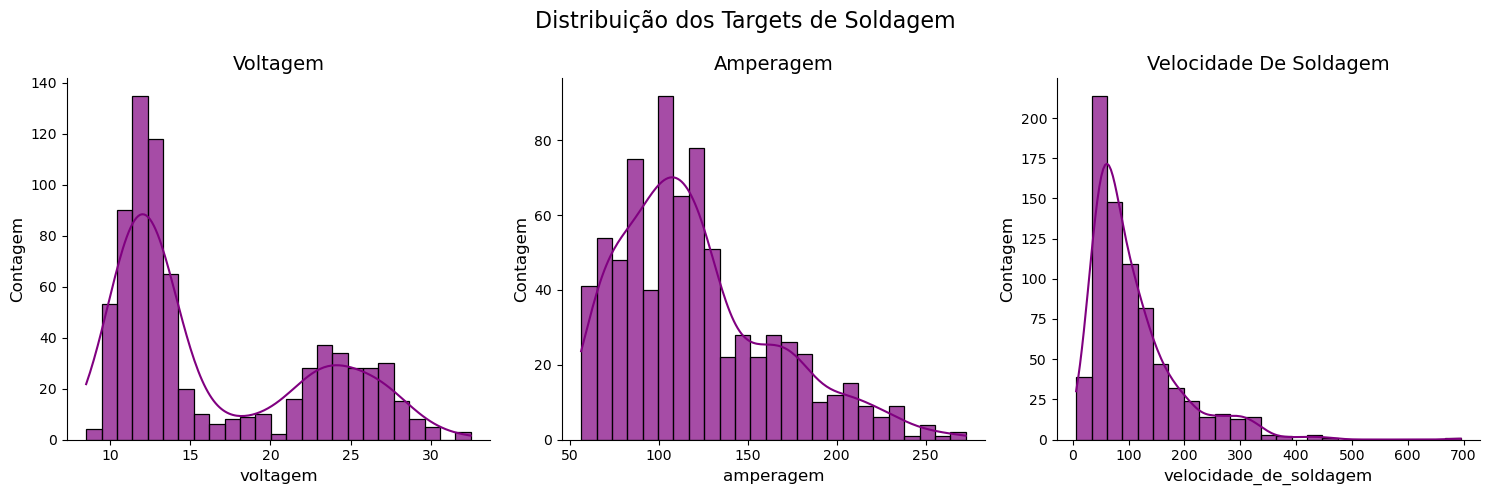

In [47]:
fig, axes = plt.subplots(1, len(targets), figsize=(15, 5))
if len(targets) == 1:
    axes = [axes]
for i, target in enumerate(targets):
    ax = axes[i] 
    sns.histplot(
        data=dados,
        x=target,
        kde=True,
        stat="count",
        bins=25,
        color='purple',  
        alpha=0.7,
        edgecolor="black",
        ax=ax,
    )
    ax.set_title(target.replace("_", " ").title(), fontsize=14)
    ax.set_xlabel(target, fontsize=12)
    ax.set_ylabel("Contagem", fontsize=12)
    sns.despine(ax=ax)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.suptitle("Distribuição dos Targets de Soldagem", fontsize=16, y=0.98)
plt.show()

Com base na análise de 762 amostras, é possível concluir que: 
- Voltagem: Apresenta distribuição bimodal, com concentração entre 10 V e 14 V, um segundo grupo entre 22 V e 28 V, e poucos dados na faixa intermediária.
- Amperagem: Distribuição assimétrica à direita, concentrando-se principalmente entre 80 A e 130 A, com cauda longa até 272.5 A.
- Velocidade de Soldagem: Variável de maior variabilidade Embora 75% dos dados estejam abaixo de 135.00, a distribuição se estende por uma cauda longa até o extremo de 700, refletindo condições operacionais bem específicas do dataset. Optou-se por não excluir outliers para manter a maior amplitude dos dados reais

### Estudo de Correlação entre Variáveis

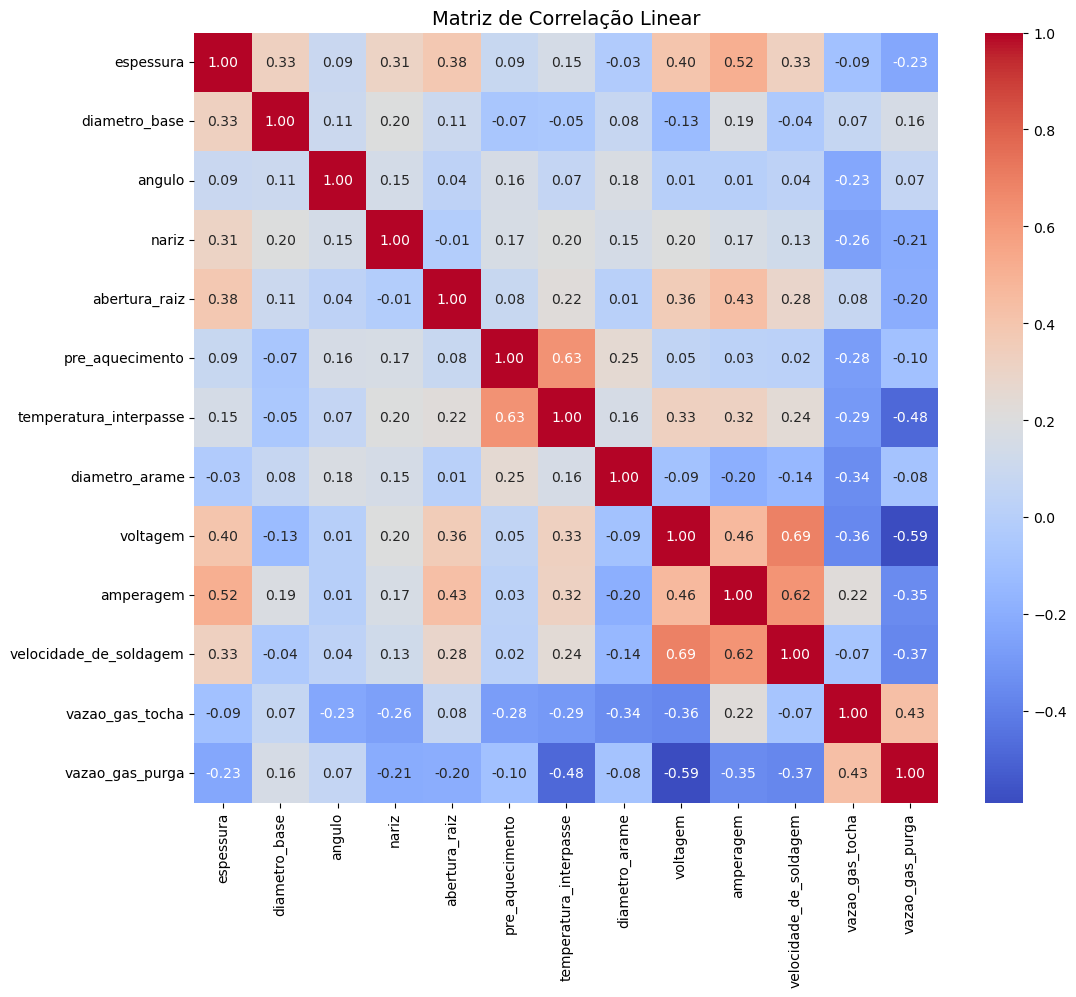

In [48]:
num_cols = dados.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(dados[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matriz de Correlação Linear', fontsize=14)
plt.show()

* Variáveis geométricas críticas, como angulo e nariz, apresentam coeficientes de correlação próximos de zero com voltagem e amperagem. Isso prova que não há uma relação em linha reta entre elas. Elas atuam por meio de interações complexas de alta dimensão, o que descarta modelos lineares simples e valida a escolha da sua Rede Neural em PyTorch.
* A matriz confirmou fortes relações lineares esperadas na soldagem, como o forte vínculo entre velocidade_de_soldagem vs. voltagem (0.68) e amperagem (0.62), além do impacto direto da material1_espessura sobre a amperagem necessária (0.50).
* Não existem problemas de multicolinearidade perfeita (correlações acima de 0.85), o que significa que nenhuma variável precisa ser descartada por redundância extrema, permitindo que a rede neural aprenda os pesos de cada recurso de entrada.

### 6. Análise das Variáveis 

Variáveis Categóricas
- Material de Adição 
- Material de Base
- Pnumber 
- Limpeza 
- Posição Peça
- Tipo Cranfro 
- Tipo Gas tocha 
- Tipo Gas Purga 
- Processo 
- Polaridade
- Norma 
- Cobre Junta
- Goivagem
- Passe
- Tipo de Peça 

Variáveis Numéricas 
- Velocidade de Soldagem 
- Amperagem 
- Voltagem 
- Espessura
- Temperatura de Interpasse
- Diametro do material de base
- Vazão Gas purga
- Vazão Gas tocha 
- Nariz
- Angulo 


In [49]:
dados.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
espessura,762.0,12.23,9.53,2.00,5.50,9.50,17.12,60.0
diametro_base,762.0,108.09,120.98,0.00,16.00,60.33,168.30,711.2
angulo,762.0,64.58,8.33,15.00,60.00,60.00,70.00,76.0
nariz,762.0,1.38,0.70,0.00,1.00,1.50,2.00,7.0
abertura_raiz,762.0,3.74,1.48,1.00,3.00,4.00,4.00,25.0
pre_aquecimento,762.0,46.56,62.79,5.00,17.25,23.00,30.00,300.0
temperatura_interpasse,762.0,161.57,72.65,53.00,100.00,150.00,223.00,350.0
diametro_arame,762.0,2.26,1.05,0.90,1.60,2.40,2.50,24.0
voltagem,762.0,16.33,6.15,8.50,11.50,13.00,22.50,32.5
amperagem,762.0,120.64,43.51,56.50,89.12,112.50,145.00,272.5


In [50]:
categorical_cols = dados.select_dtypes(include=['object']).columns
dados[categorical_cols].describe().T

,count,unique,top,freq
normas_referencia,762,3,ASME IX,699
pnumber,762,13,1,259
material_base,762,71,A790S32750,95
tipo_peca,762,2,tubo,573
tipo_chanfro,762,5,V,666
cobre_junta,762,3,False,379
goivagem,762,3,Informação Desconhecida,632
posicao_peca,762,6,6G,465
progressao,762,3,ASCENDENTE,573
passe,762,3,acabamento,257


In [51]:
for c in dados.nunique().sort_values(ascending=False).index:
    print(f'{c}: {dados[c].nunique()} valores únicos')

velocidade_de_soldagem: 338 valores únicos
amperagem: 213 valores únicos
voltagem: 115 valores únicos
espessura: 80 valores únicos
material_adicao: 72 valores únicos
material_base: 71 valores únicos
temperatura_interpasse: 59 valores únicos
pre_aquecimento: 50 valores únicos
diametro_base: 35 valores únicos
vazao_gas_tocha: 27 valores únicos
diametro_arame: 21 valores únicos
abertura_raiz: 20 valores únicos
vazao_gas_purga: 19 valores únicos
pureza_gas_tocha: 18 valores únicos
angulo: 14 valores únicos
pnumber: 13 valores únicos
nariz: 13 valores únicos
pureza_gas_purga: 11 valores únicos
limpeza: 8 valores únicos
posicao_peca: 6 valores únicos
tipo_gas_tocha: 6 valores únicos
tipo_chanfro: 5 valores únicos
processo: 4 valores únicos
tipo_gas_purga: 4 valores únicos
polaridade: 4 valores únicos
normas_referencia: 3 valores únicos
goivagem: 3 valores únicos
cobre_junta: 3 valores únicos
progressao: 3 valores únicos
passe: 3 valores únicos
tipo_peca: 2 valores únicos


### Pré processamento dos Dados

In [ ]:
gases = ["AR", "CO2", "O2", "N2"]

#FUNÇÃO DE PROCESSAMENTO E LIMPEZA COM REGEX
# Essa função isola os textos de tipo e pureza de uma única linha.
# Regex para varrer as strings e extrair apenas os nomes dos gases e seus valores numéricos,
# Sem Gás = 1 se True, else = 0 
def processar_gas(row, pref):
    tipo, pureza = (str(row[f"tipo_gas_{pref}"]),str(row[f"pureza_gas_{pref}"]))
    res = {f"{pref}_{g}": 0.0 for g in gases}
    res[f"{pref}_SemGas"] = int("Sem Gás" in tipo or tipo in ["0", "nan"])
    gases_f = re.findall(r"AR|CO2|O2|N2", tipo)
    numeros_f = [float(n) for n in re.findall(r"\d+\.?\d*", pureza)]
    for g, v in zip(gases_f, numeros_f):
        res[f"{pref}_{g}"] = v
    return pd.Series(res)

for p in ["tocha", "purga"]:
    dados = dados.join(dados.apply(processar_gas, axis=1, args=(p,)))

dados = dados.drop(columns=["tipo_gas_tocha","pureza_gas_tocha","tipo_gas_purga","pureza_gas_purga"],errors="ignore",)

cols_gases = [f"{p}_{g}" for p in ["tocha", "purga"] for g in gases + ["SemGas"]]
outras_cols = [c for c in dados.columns if c not in cols_gases]
dados = dados[outras_cols + cols_gases]

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

def preparar_dados(dados):
    df = dados.copy()
    target_cols = ['voltagem', 'amperagem', 'velocidade_de_soldagem']
    X = df.drop(columns=target_cols)
    y = df[target_cols]

    # FEATURES NUMÉRICAS
    features_numericas = ['espessura','diametro_base','angulo','nariz','abertura_raiz','pre_aquecimento','temperatura_interpasse','diametro_arame','vazao_gas_tocha','vazao_gas_purga' ]

    # FEATURES CATEGÓRICAS
    features_onehot = ['tipo_peca', 'passe', 'goivagem', 'cobre_junta','polaridade', 'progressao', 'processo','normas_referencia', 'tipo_chanfro','posicao_peca', 'limpeza', 'pnumber' ]
    features_embedding = ['material_base','material_adicao']
    colunas_gas = ['tocha_AR', 'purga_AR', 'tocha_CO2', 'purga_CO2', 'tocha_O2', 'purga_O2', 'tocha_N2','purga_N2', 'tocha_SemGas', 'purga_SemGas']
    categoricas = features_onehot + features_embedding + colunas_gas
    for col in features_onehot + features_embedding:
        if col in X.columns:
            X[col] = X[col].astype(str)

    # SPLIT
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

    # PREPROCESSADOR
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), features_numericas),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_onehot),
            ('embed', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), features_embedding)
        ],
    )
    # TRANSFORMAÇÃO
    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)
    return (X_train_enc,X_test_enc, y_train.values, y_test.values,features_numericas,categoricas,preprocessor)

In [54]:
X_train_enc, X_test_enc, y_train, y_test, num_feats, cat_feats, preprocessor_enc = preparar_dados(dados)

In [55]:
print("X_train:", X_train_enc.shape)
print("X_test:", X_test_enc.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (609, 68)
X_test: (153, 68)
y_train: (609, 3)
y_test: (153, 3)


In [56]:
print("NaNs treino:", np.isnan(X_train_enc).sum())
print("NaNs teste:", np.isnan(X_test_enc).sum())

NaNs treino: 0
NaNs teste: 0


In [57]:
dados

,normas_referencia,pnumber,material_base,espessura,diametro_base,tipo_peca,tipo_chanfro,angulo,nariz,abertura_raiz,...,tocha_AR,tocha_CO2,tocha_O2,tocha_N2,tocha_SemGas,purga_AR,purga_CO2,purga_O2,purga_N2,purga_SemGas
0,AWS,1,API5LX52,11.00,204.0,tubo,V,60.0,2.0,3.0,...,0.000,0.0,0.0,0.0,1.0,0.00,0.0,0.0,0.0,1.0
1,ASME IX,1,A51660,12.70,0.0,chapa,V,70.0,2.0,4.0,...,99.996,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0
2,ASME IX,1,A51660,12.70,0.0,chapa,V,70.0,2.0,4.0,...,99.996,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0
3,ASME IX,1,A51670,31.00,0.0,chapa,V,75.0,2.0,4.5,...,99.996,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0
4,ASME IX,1,A51670,31.00,0.0,chapa,V,75.0,2.0,4.0,...,0.000,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
898,ASME IX,10H,A790S31803,5.49,88.9,tubo,V,60.0,1.0,3.0,...,98.000,0.0,0.0,2.0,0.0,98.00,0.0,0.0,2.0,0.0
899,ASME IX,43,B564N06625,23.01,219.1,tubo,U,70.0,1.5,3.0,...,99.990,0.0,0.0,0.0,0.0,99.99,0.0,0.0,0.0,0.0
900,ASME IX,10H,A790S32750,8.18,219.1,tubo,V,70.0,3.0,3.0,...,98.000,0.0,0.0,2.0,0.0,98.00,0.0,0.0,2.0,0.0
901,ASME IX,10H,A790S32750,18.26,219.1,tubo,V,70.0,3.0,3.0,...,98.000,0.0,0.0,2.0,0.0,98.00,0.0,0.0,2.0,0.0
